Tutorial de Proyecto de Regresión 

Predecir el coste del seguro médico de una persona

Cargando librerias 

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import math
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import matplotlib.gridspec as gridspec

In [54]:
url = "https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv"
df = pd.read_csv(url)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [55]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


In [56]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [57]:
df.shape

(1338, 7)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [59]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

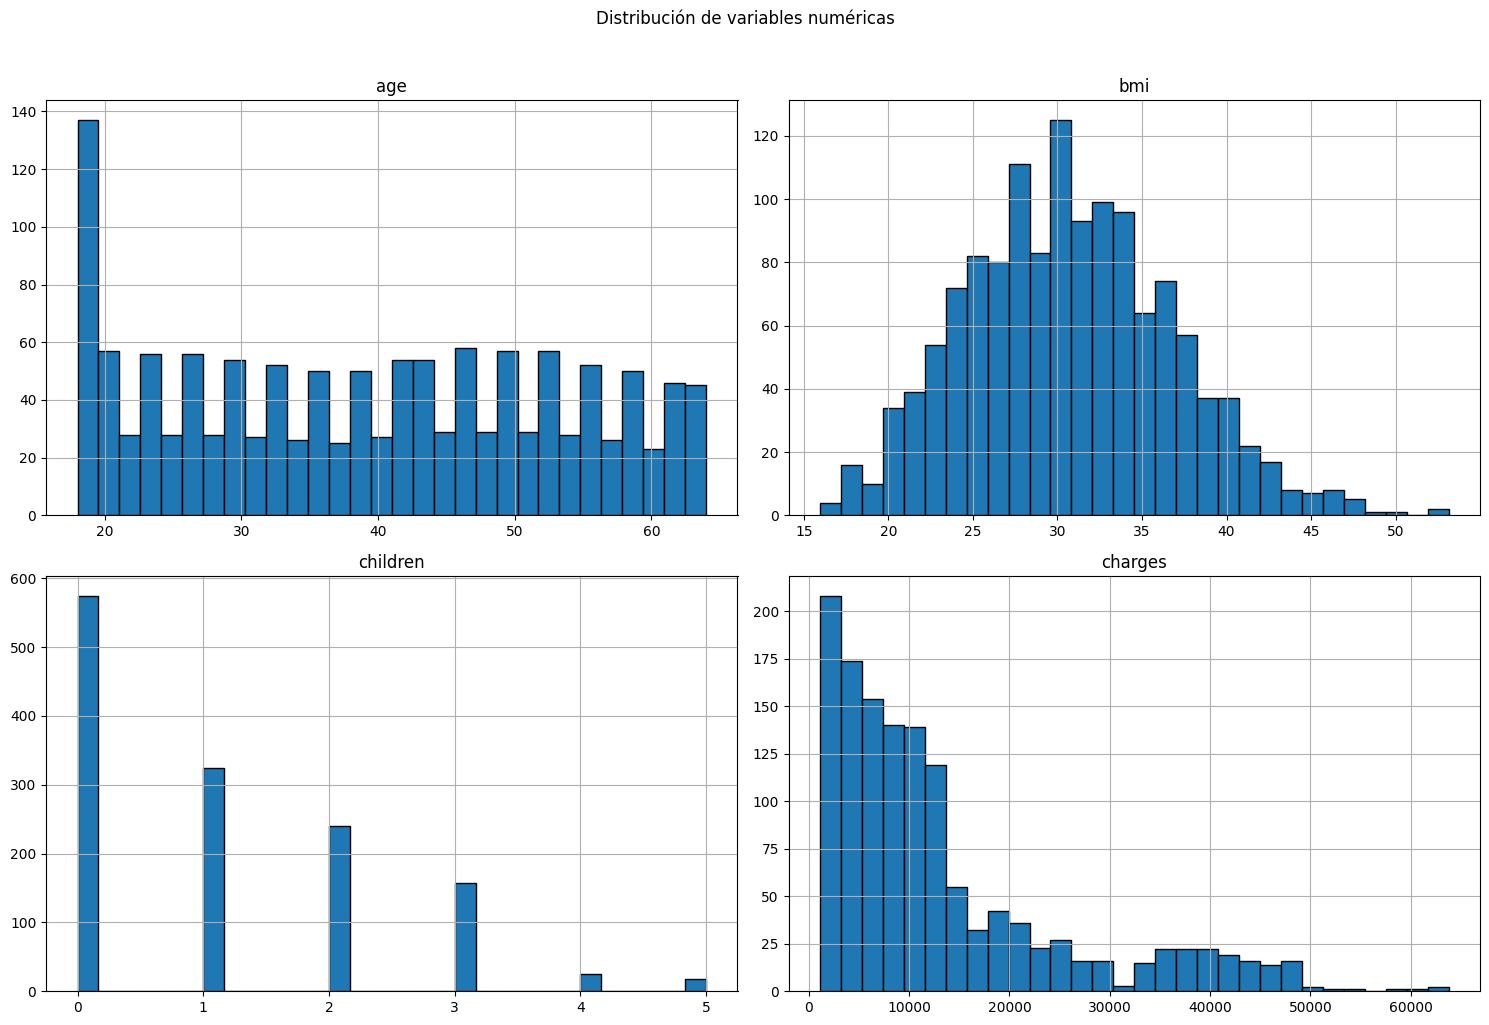

In [60]:

df.hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Distribución de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

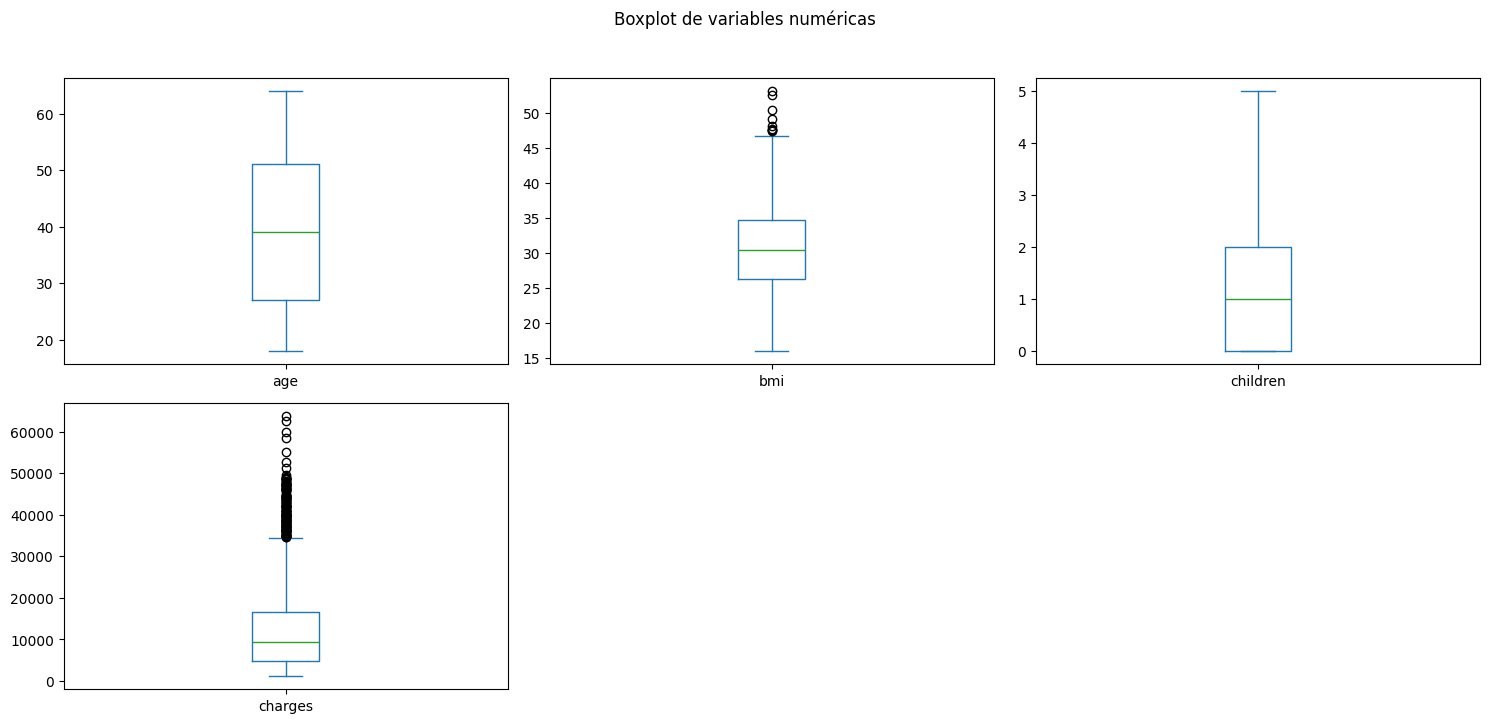

In [61]:
df.select_dtypes(include="number").plot(kind="box", figsize=(15, 10), subplots=True, layout=(3, 3))
plt.suptitle("Boxplot de variables numéricas", y=1.02)
plt.tight_layout()
plt.show()

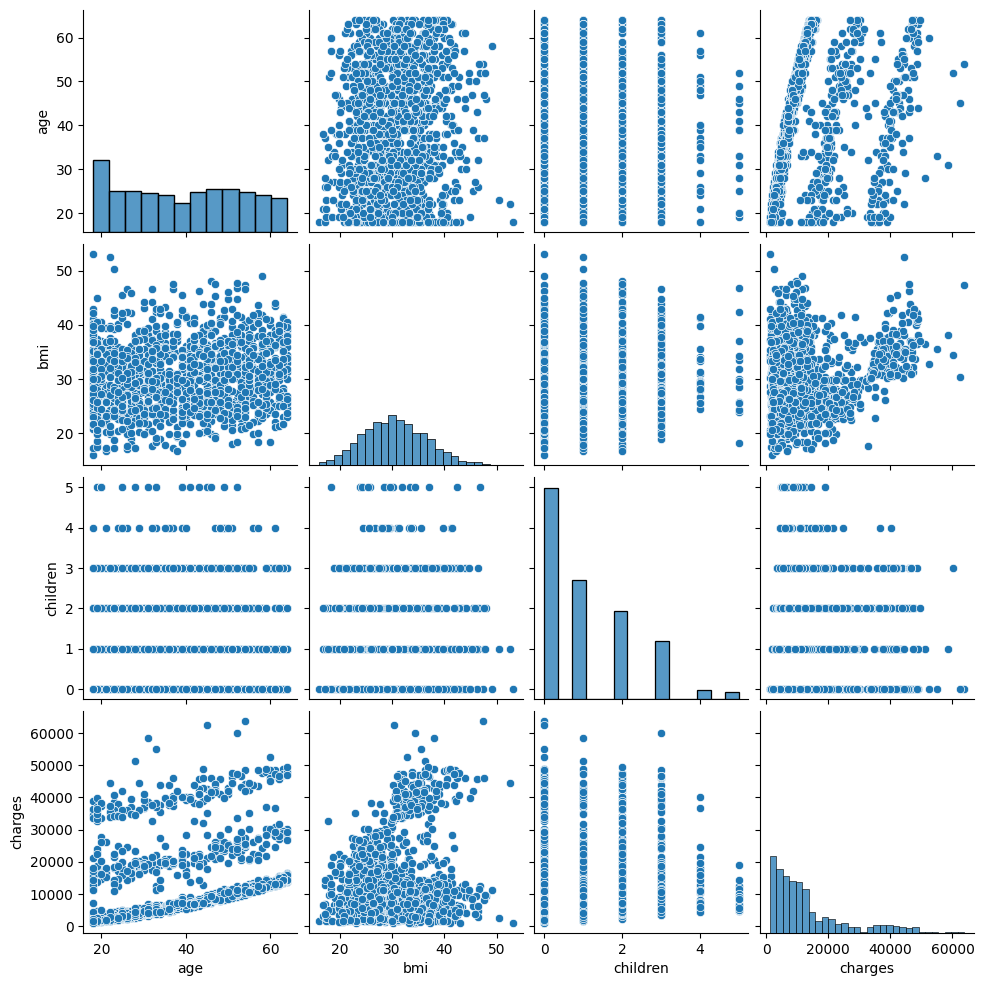

In [62]:

sns.pairplot(df.select_dtypes(include="number"))
plt.show()

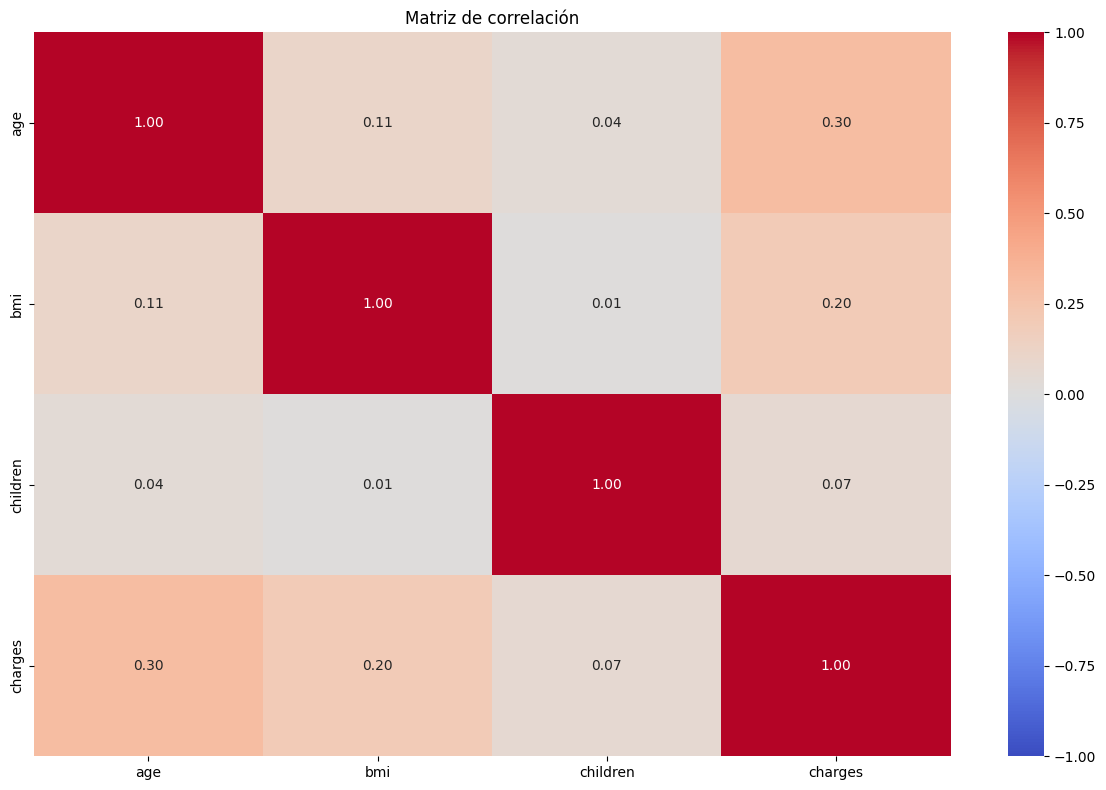

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

In [64]:

numericas = df.select_dtypes(include="number")

resumen = pd.DataFrame({
    "mean":     numericas.mean(),
    "median":   numericas.median(),
    "std":      numericas.std(),
    "variance": numericas.var(),
    "skewness": numericas.skew(),
    "kurtosis": numericas.kurt(),
    "IQR":      numericas.quantile(0.75) - numericas.quantile(0.25)
})

print(resumen)

                  mean    median           std      variance  skewness  \
age          39.207025    39.000     14.049960  1.974014e+02  0.055673   
bmi          30.663397    30.400      6.098187  3.718788e+01  0.284047   
children      1.094918     1.000      1.205493  1.453213e+00  0.938380   
charges   13270.422265  9382.033  12110.011237  1.466524e+08  1.515880   

          kurtosis           IQR  
age      -1.245088     24.000000  
bmi      -0.050732      8.397500  
children  0.202454      2.000000  
charges   1.606299  11899.625365  


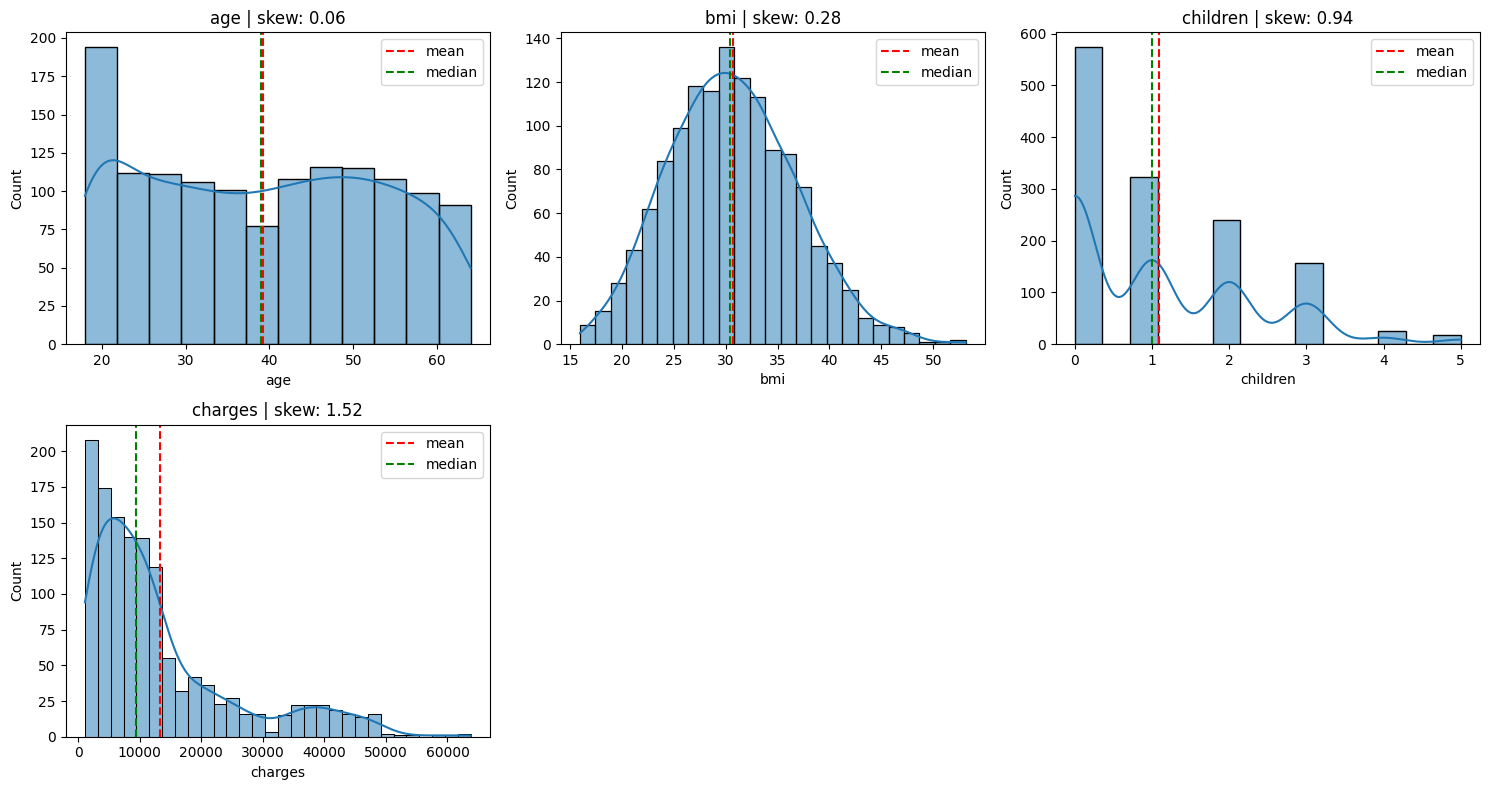

In [65]:
numericas = df.select_dtypes(include="number").columns
ncols = 3
nrows = math.ceil(len(numericas) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(numericas):
    sns.histplot(df[col], kde=True, ax=axes[i])
    skew_val = df[col].skew()
    axes[i].set_title(f"{col} | skew: {skew_val:.2f}")
    axes[i].axvline(df[col].mean(),   color="red",   linestyle="--", label="mean")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label="median")
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Making categorical variables to numerical data to start working on the linear regression 

In [66]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [67]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [68]:

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

RMSE: 5796.28
R² Score: 0.7836


In [69]:
print(df['charges'].describe())

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


In [70]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 


model_ridge = Ridge(alpha=10)
model_ridge.fit(X_train_scaled, y_train)
y_pred_ridge = model_ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"RMSE Ridge: {rmse_ridge:.2f}")
print(f"R² Ridge:   {r2_ridge:.4f}")

RMSE Ridge: 5803.95
R² Ridge:   0.7830


we let the original model given that there is no real change at the time to improve it 

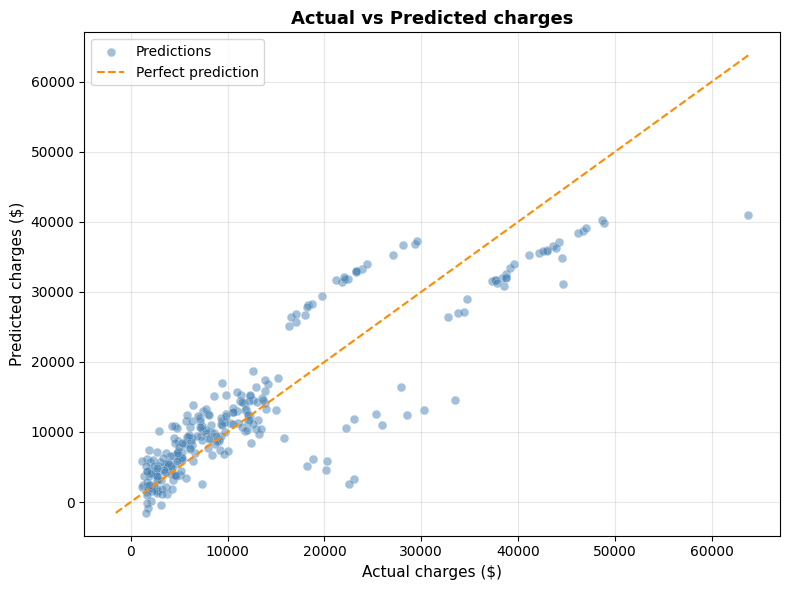

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue',
            edgecolors='white', linewidths=0.3, s=40, label='Predictions')


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         color='darkorange', linestyle='--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual charges ($)', fontsize=11)
plt.ylabel('Predicted charges ($)', fontsize=11)
plt.title('Actual vs Predicted charges', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

En la gráfica se puede ver que el modelo predice bastante bien los costos del seguro, ya que la mayoría de los puntos se encuentran cerca de la línea naranja, que representa una predicción perfecta. Donde más se aleja es en los costos muy altos, lo cual es normal dado que son casos más difíciles de predecir.
Se probó también un modelo Ridge para intentar mejorar los resultados, pero los valores obtenidos fueron prácticamente iguales. Por eso se decidió mantener el modelo de Regresión Lineal original, ya que es más sencillo y funciona igual de bien.